# Food Delivery ETA Prediction - Exploratory Data Analysis

**Notebook:** 02_eda.ipynb
**Purpose:** Explore patterns and relationships in the raw dataset

This notebook performs comprehensive exploratory data analysis to understand patterns, relationships, and insights from the raw dataset without permanent preprocessing.

## EDA Objective

Explore patterns and relationships in the raw dataset to understand:
- Data distributions
- Feature relationships
- Potential outliers
- Correlations with target
- Insights for preprocessing and feature engineering

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Load Dataset

In [2]:
df = pd.read_csv('../data/raw/Food_Delivery_Times.csv')
print(f"Dataset loaded: {df.shape}")

Dataset loaded: (1000, 9)


## Missing-Value Analysis

In [3]:
# Calculate missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_count.values,
    'Missing %': missing_percentage.values
})

missing_table = missing_table.sort_values('Missing Count', ascending=False)

print("Missing Value Analysis:")
print(missing_table[missing_table['Missing Count'] > 0])

print(f"\nTotal missing values: {missing_count.sum()}")
print(f"Columns with missing values: {missing_count[missing_count > 0].count()}")

Missing Value Analysis:
                   Column  Missing Count  Missing %
2                 Weather             30        3.0
3           Traffic_Level             30        3.0
4             Time_of_Day             30        3.0
7  Courier_Experience_yrs             30        3.0

Total missing values: 120
Columns with missing values: 4


## Duplicate Analysis

In [4]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Rows: {duplicate_count}")
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

if duplicate_count > 0:
    print("\nDuplicates exist and will need investigation in data cleaning.")
else:
    print("\nNo duplicate rows found.")

Duplicate Rows: 0
Duplicate Percentage: 0.00%

No duplicate rows found.


## Numerical Feature Distributions

In [5]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
target_variable = 'Delivery_Time_min'
predictor_numerical = [col for col in numerical_features if col != target_variable and col != 'Order_ID']

print(f"Numerical Predictors: {predictor_numerical}")
print(f"\nStatistical Summary:")
print(df[predictor_numerical].describe())

Numerical Predictors: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

Statistical Summary:
       Distance_km  Preparation_Time_min  Courier_Experience_yrs
count  1000.000000           1000.000000              970.000000
mean     10.059970             16.982000                4.579381
std       5.696656              7.204553                2.914394
min       0.590000              5.000000                0.000000
25%       5.105000             11.000000                2.000000
50%      10.190000             17.000000                5.000000
75%      15.017500             23.000000                7.000000
max      19.990000             29.000000                9.000000


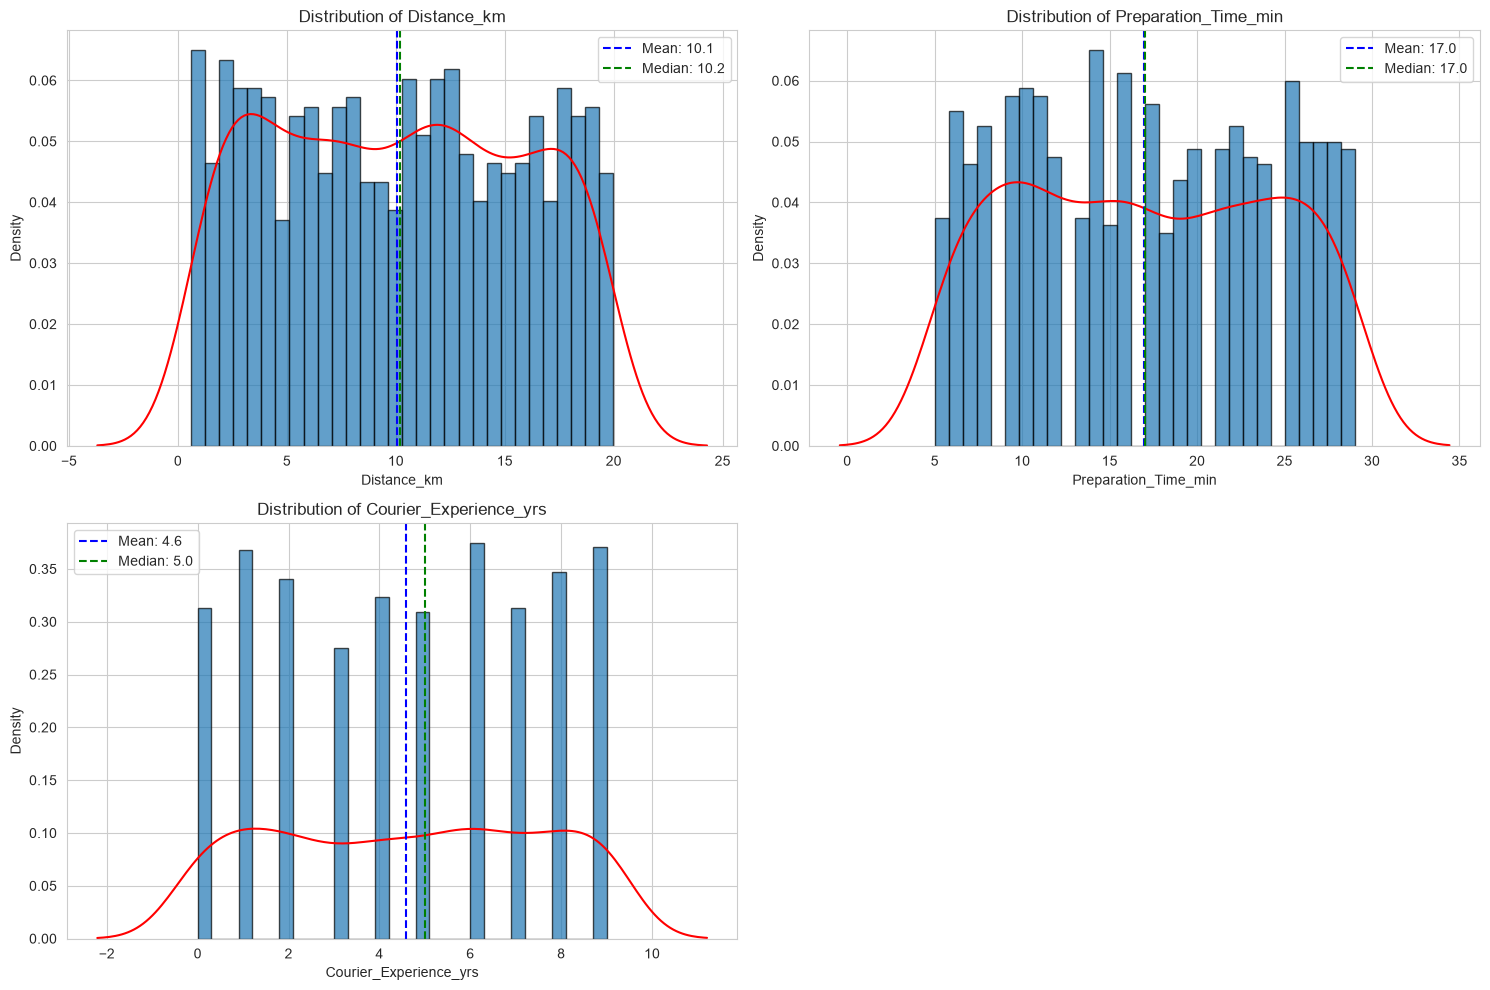

In [6]:
# Distribution plots
n_features = len(predictor_numerical)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(predictor_numerical):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, density=True)
    sns.kdeplot(df[col].dropna(), ax=axes[idx], color='red')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].axvline(df[col].mean(), color='blue', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[idx].legend()

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Categorical Feature Distributions

Categorical Features: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


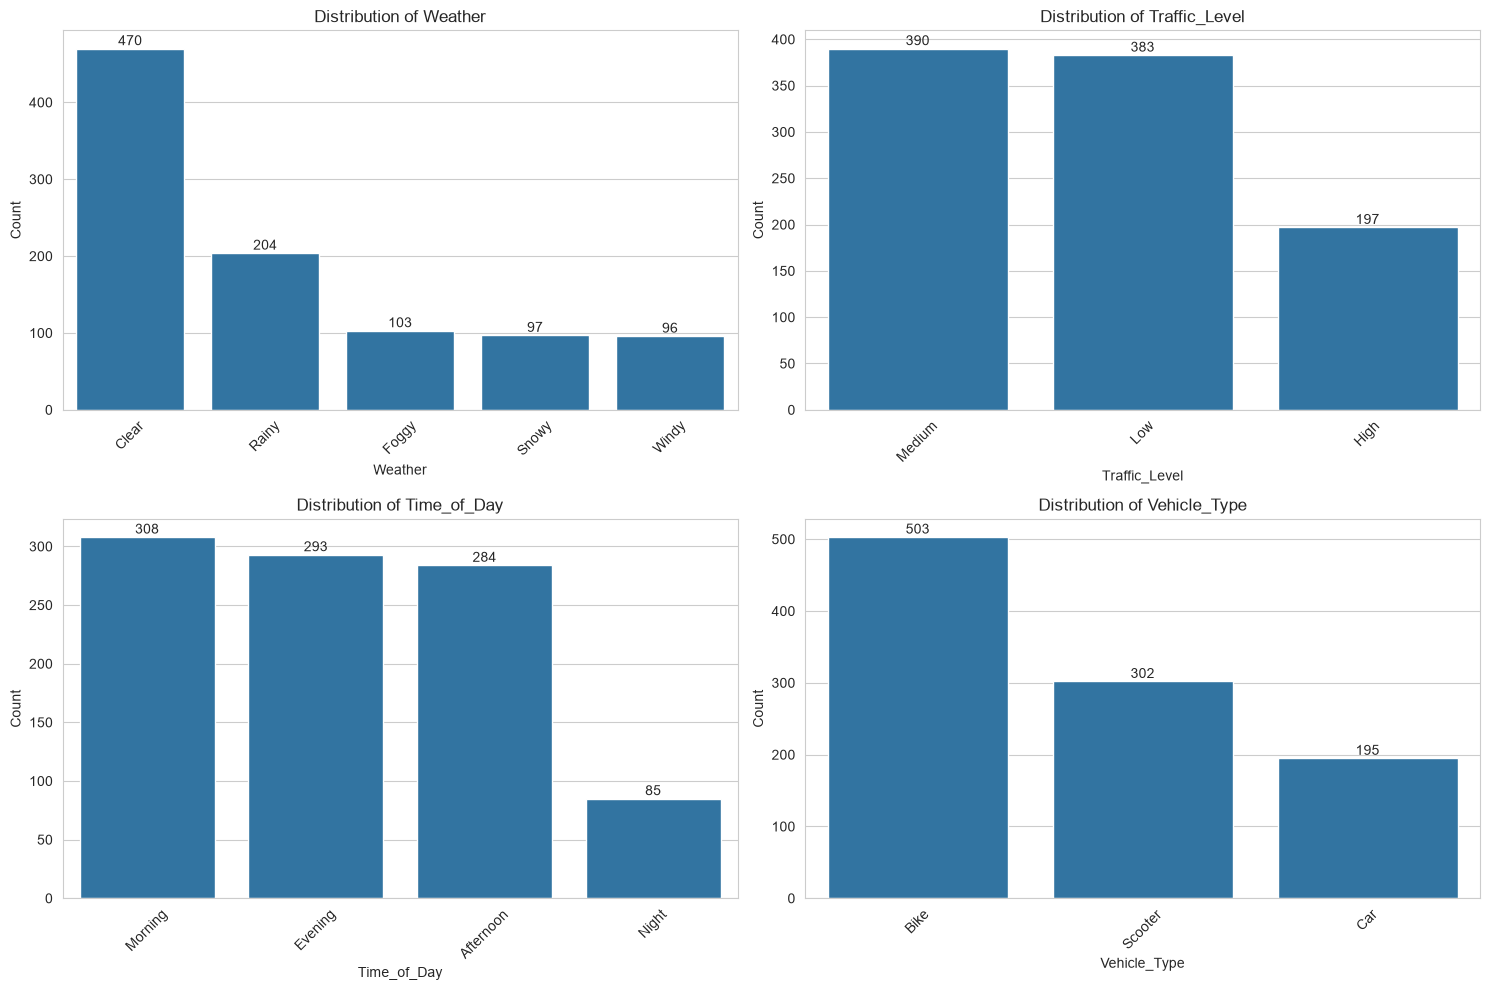

In [7]:
categorical_features = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f"Categorical Features: {categorical_features}")

# Count plots
n_cat_features = len(categorical_features)
n_cols = 2
n_rows = (n_cat_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_cat_features > 1 else [axes]

for idx, col in enumerate(categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[idx], order=order)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].tick_params(axis='x', rotation=45)

    # Add count labels on bars
    for p in axes[idx].patches:
        axes[idx].annotate(f'{int(p.get_height())}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center',
                           xytext=(0, 5), textcoords='offset points')

for idx in range(n_cat_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Target Distribution

In [8]:
target = 'Delivery_Time_min'

print(f"Target Variable Statistics: {target}")
print(f"Mean: {df[target].mean():.2f}")
print(f"Median: {df[target].median():.2f}")
print(f"Standard Deviation: {df[target].std():.2f}")
print(f"Minimum: {df[target].min():.2f}")
print(f"Maximum: {df[target].max():.2f}")
print(f"Skewness: {df[target].skew():.2f}")

Target Variable Statistics: Delivery_Time_min
Mean: 56.73
Median: 55.50
Standard Deviation: 22.07
Minimum: 8.00
Maximum: 153.00
Skewness: 0.51


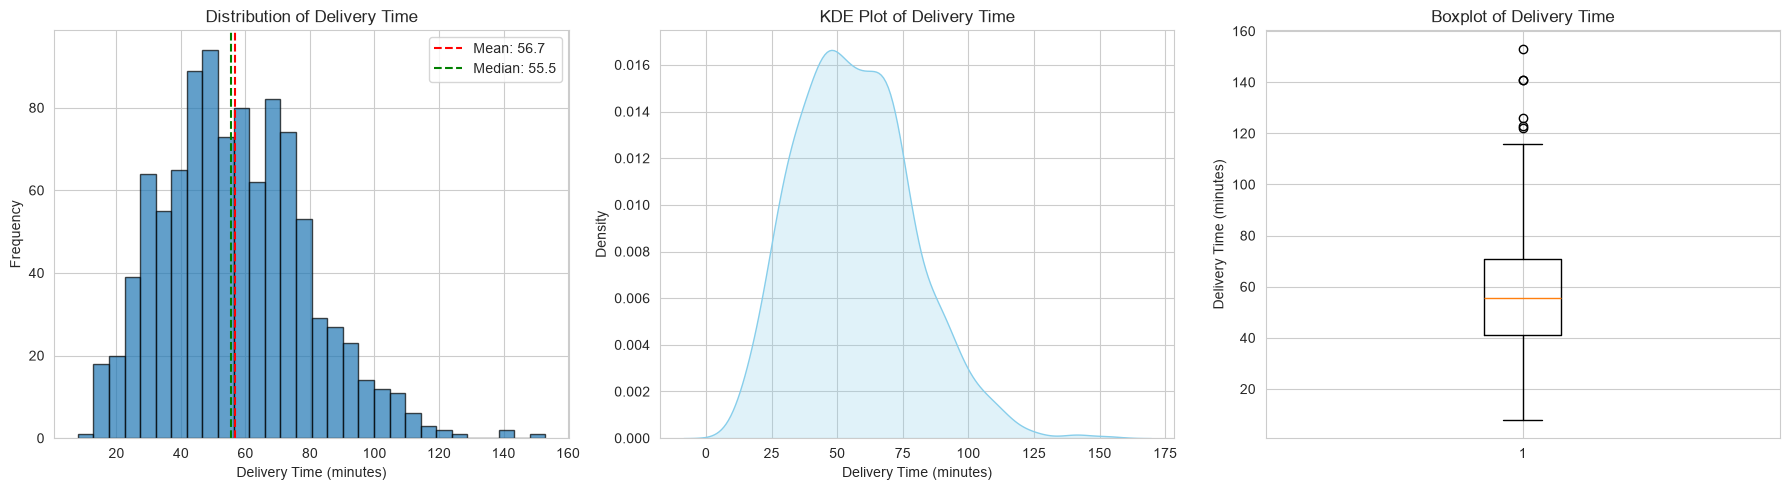

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df[target], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Delivery Time (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Delivery Time')
axes[0].axvline(df[target].mean(), color='red', linestyle='--', label=f'Mean: {df[target].mean():.1f}')
axes[0].axvline(df[target].median(), color='green', linestyle='--', label=f'Median: {df[target].median():.1f}')
axes[0].legend()

# KDE Plot
sns.kdeplot(df[target], ax=axes[1], fill=True, color='skyblue')
axes[1].set_xlabel('Delivery Time (minutes)')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE Plot of Delivery Time')

# Boxplot
axes[2].boxplot(df[target], vert=True)
axes[2].set_ylabel('Delivery Time (minutes)')
axes[2].set_title('Boxplot of Delivery Time')

plt.tight_layout()
plt.show()

## Boxplots for Numerical Variables

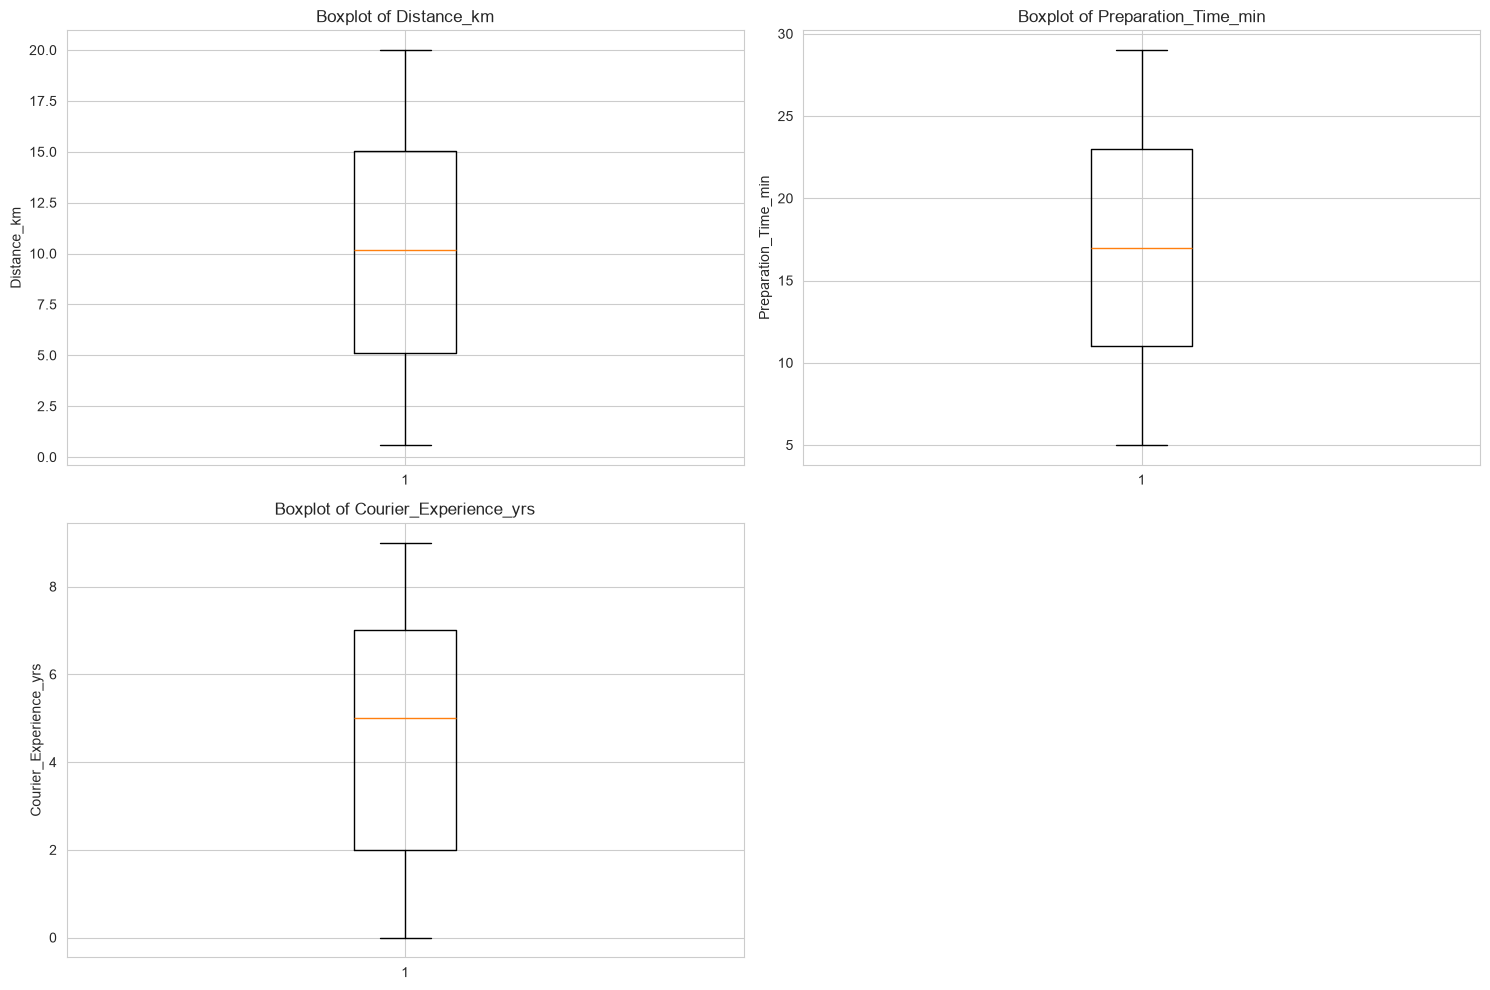

In [10]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(predictor_numerical):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_ylabel(col)
    axes[idx].set_title(f'Boxplot of {col}')

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Numerical Features vs Target

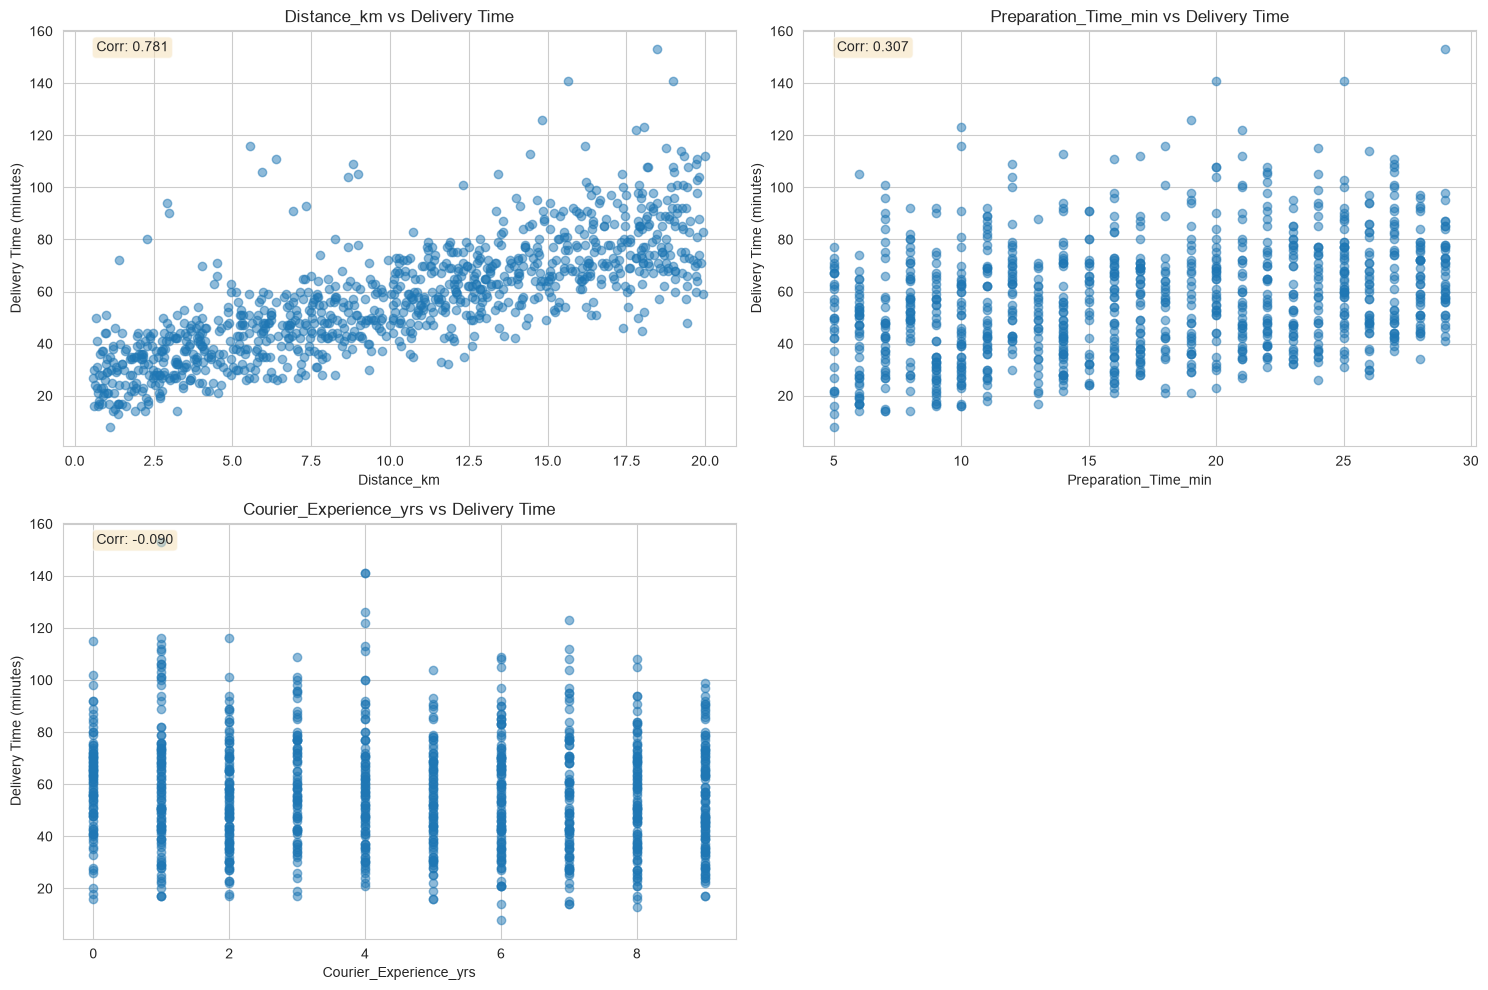

In [11]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(predictor_numerical):
    axes[idx].scatter(df[col], df[target], alpha=0.5)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Delivery Time (minutes)')
    axes[idx].set_title(f'{col} vs Delivery Time')

    # Add correlation line
    valid_data = df[[col, target]].dropna()
    if len(valid_data) > 0:
        corr = valid_data[col].corr(valid_data[target])
        axes[idx].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[idx].transAxes,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Categorical Features vs Target

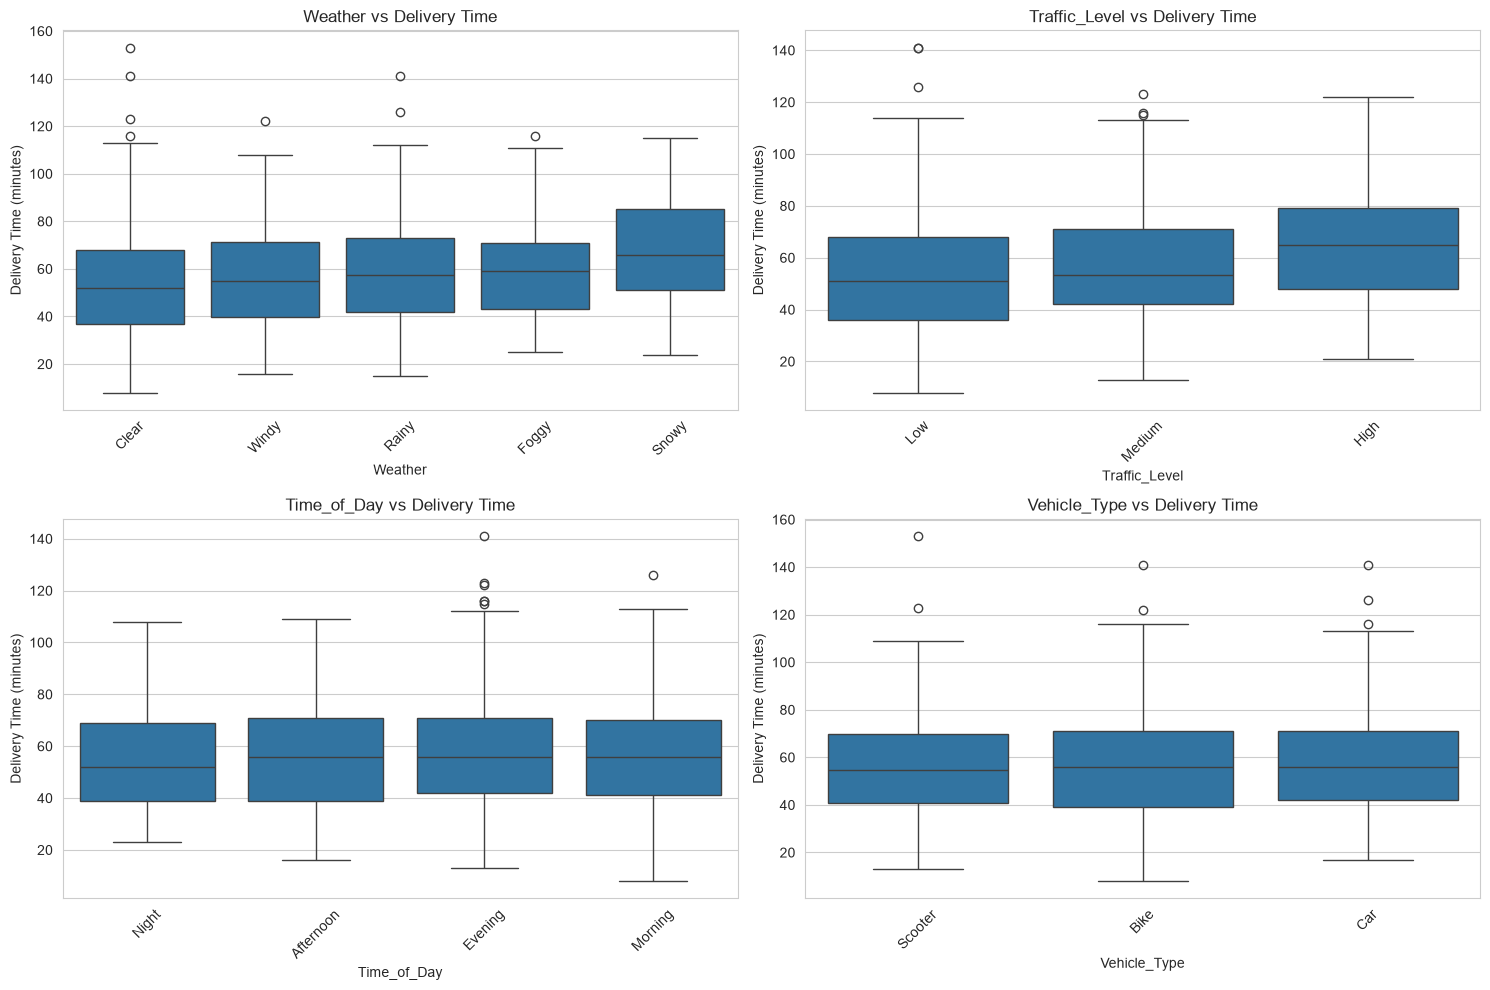

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_cat_features > 1 else [axes]

for idx, col in enumerate(categorical_features):
    order = df.groupby(col)[target].median().sort_values().index
    sns.boxplot(data=df, x=col, y=target, ax=axes[idx], order=order)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Delivery Time (minutes)')
    axes[idx].set_title(f'{col} vs Delivery Time')
    axes[idx].tick_params(axis='x', rotation=45)

for idx in range(n_cat_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation Analysis

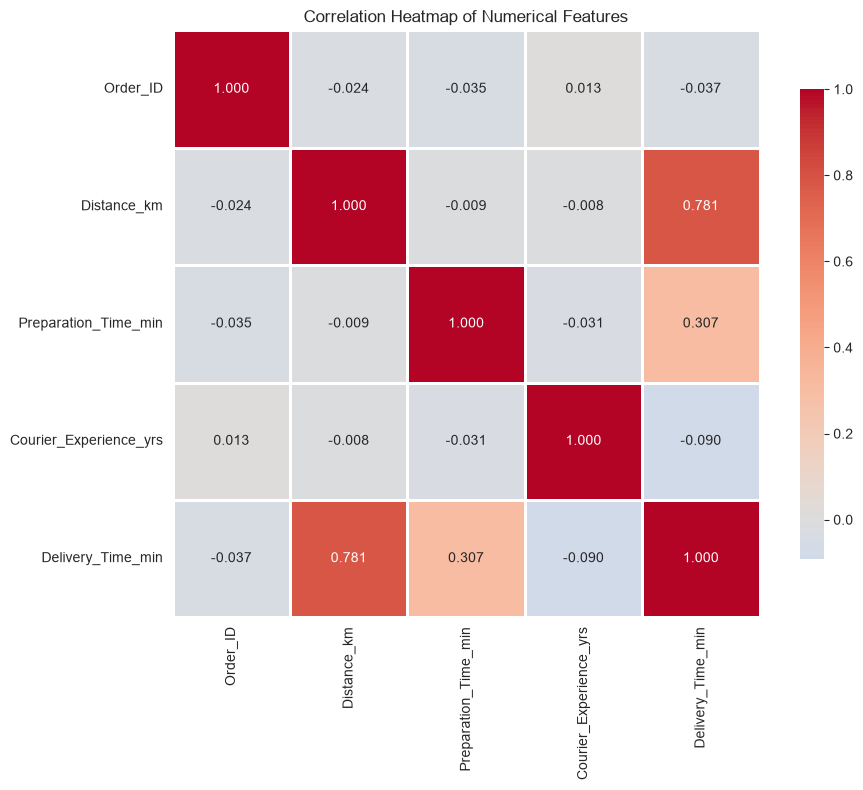

In [13]:
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [14]:
target_correlation = correlation_matrix[target_variable].sort_values(ascending=False)

print(f"Correlation with {target_variable}:")
print(target_correlation)

print("\nInterpretation:")
print("- Values closer to 1: Strong positive correlation")
print("- Values closer to -1: Strong negative correlation")
print("- Values closer to 0: Weak or no correlation")

Correlation with Delivery_Time_min:
Delivery_Time_min         1.000000
Distance_km               0.780998
Preparation_Time_min      0.307350
Order_ID                 -0.036650
Courier_Experience_yrs   -0.090433
Name: Delivery_Time_min, dtype: float64

Interpretation:
- Values closer to 1: Strong positive correlation
- Values closer to -1: Strong negative correlation
- Values closer to 0: Weak or no correlation


## Outlier Analysis

In [15]:
print("IQR-based Outlier Analysis:")
outlier_summary = []

for col in predictor_numerical:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        'Feature': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier %': outlier_percentage
    })

    print(f"{col}: {outlier_count} outliers ({outlier_percentage:.2f}%)")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

outlier_df = pd.DataFrame(outlier_summary)
print("\nOutlier Summary Table:")
print(outlier_df)

IQR-based Outlier Analysis:
Distance_km: 0 outliers (0.00%)
  Bounds: [-9.76, 29.89]
Preparation_Time_min: 0 outliers (0.00%)
  Bounds: [-7.00, 41.00]
Courier_Experience_yrs: 0 outliers (0.00%)
  Bounds: [-5.50, 14.50]

Outlier Summary Table:
                  Feature  Lower Bound  Upper Bound  Outlier Count  Outlier %
0             Distance_km     -9.76375     29.88625              0        0.0
1    Preparation_Time_min     -7.00000     41.00000              0        0.0
2  Courier_Experience_yrs     -5.50000     14.50000              0        0.0


## Skewness Analysis

In [16]:
print("Skewness Analysis:")
for col in predictor_numerical + [target_variable]:
    skewness = df[col].skew()
    print(f"{col}: {skewness:.3f}")

    if abs(skewness) < 0.5:
        interpretation = "approximately symmetric"
    elif abs(skewness) < 1:
        interpretation = "moderately skewed"
    else:
        interpretation = "highly skewed"
    print(f"  Interpretation: {interpretation}")

Skewness Analysis:
Distance_km: 0.039
  Interpretation: approximately symmetric
Preparation_Time_min: 0.030
  Interpretation: approximately symmetric
Courier_Experience_yrs: -0.029
  Interpretation: approximately symmetric
Delivery_Time_min: 0.507
  Interpretation: moderately skewed


## Relationship Analysis

In [17]:
print("Key Relationships Analysis:")
print("="*60)

# Distance vs Delivery Time
dist_corr = df['Distance_km'].corr(df[target])
print(f"\n1. Distance vs Delivery Time:")
print(f"   Correlation: {dist_corr:.3f}")
print(f"   Interpretation: {'Strong positive relationship' if abs(dist_corr) > 0.5 else 'Moderate relationship' if abs(dist_corr) > 0.3 else 'Weak relationship'}")

# Preparation Time vs Delivery Time
prep_corr = df['Preparation_Time_min'].corr(df[target])
print(f"\n2. Preparation Time vs Delivery Time:")
print(f"   Correlation: {prep_corr:.3f}")
print(f"   Interpretation: {'Strong positive relationship' if abs(prep_corr) > 0.5 else 'Moderate relationship' if abs(prep_corr) > 0.3 else 'Weak relationship'}")

# Courier Experience vs Delivery Time
exp_corr = df['Courier_Experience_yrs'].corr(df[target])
print(f"\n3. Courier Experience vs Delivery Time:")
print(f"   Correlation: {exp_corr:.3f}")
print(f"   Interpretation: {'Strong negative relationship' if exp_corr < -0.5 else 'Moderate relationship' if abs(exp_corr) > 0.3 else 'Weak relationship'}")

Key Relationships Analysis:

1. Distance vs Delivery Time:
   Correlation: 0.781
   Interpretation: Strong positive relationship

2. Preparation Time vs Delivery Time:
   Correlation: 0.307
   Interpretation: Moderate relationship

3. Courier Experience vs Delivery Time:
   Correlation: -0.090
   Interpretation: Weak relationship


## Categorical Feature Impact Analysis

In [18]:
print("Categorical Feature Impact on Delivery Time:")
print("="*60)

for col in categorical_features:
    print(f"\n{col}:")
    grouped_stats = df.groupby(col)[target].agg(['count', 'mean', 'median', 'std'])
    print(grouped_stats)

    # Calculate variation
    variation = grouped_stats['std'].mean() / grouped_stats['mean'].mean()
    print(f"Coefficient of variation: {variation:.3f}")

Categorical Feature Impact on Delivery Time:

Weather:
         count       mean  median        std
Weather                                     
Clear      470  53.082979    52.0  21.272211
Foggy      103  59.466019    59.0  20.862207
Rainy      204  59.794118    57.5  22.822441
Snowy       97  67.113402    66.0  21.291565
Windy       96  55.458333    55.0  21.777785
Coefficient of variation: 0.366

Traffic_Level:
               count       mean  median        std
Traffic_Level                                     
High             197  64.807107    65.0  21.869356
Low              383  52.885117    51.0  21.683646
Medium           390  56.020513    53.5  21.186516
Coefficient of variation: 0.373

Time_of_Day:
             count       mean  median        std
Time_of_Day                                     
Afternoon      284  56.080986    56.0  21.085987
Evening        293  57.481229    56.0  22.176375
Morning        308  56.120130    56.0  21.539643
Night           85  55.211765    52.

## EDA Conclusions

In [19]:
print("="*60)
print("EDA CONCLUSIONS")
print("="*60)

print("\nDATA QUALITY:")
print(f"- Missing values: {missing_count.sum()} total (3% of data)")
print(f"- Affected columns: {missing_count[missing_count > 0].index.tolist()}")
print(f"- No duplicate rows found")
print(f"- No invalid negative values detected")

print("\nTARGET DISTRIBUTION:")
print(f"- Delivery Time: Mean = {df[target].mean():.1f} min, Median = {df[target].median():.1f} min")
print(f"- Range: {df[target].min():.0f} - {df[target].max():.0f} minutes")
print(f"- Skewness: {df[target].skew():.3f} (approximately symmetric)")
print(f"- Distribution appears suitable for regression")

print("\nKEY FEATURE RELATIONSHIPS:")
print(f"- Distance vs Delivery Time: Correlation = {df['Distance_km'].corr(df[target]):.3f}")
print(f"- Preparation Time vs Delivery Time: Correlation = {df['Preparation_Time_min'].corr(df[target]):.3f}")
print(f"- Courier Experience vs Delivery Time: Correlation = {df['Courier_Experience_yrs'].corr(df[target]):.3f}")

print("\nCATEGORICAL IMPACT:")
print("- Weather conditions show variation in delivery times")
print("- Traffic levels have distinct delivery time patterns")
print("- Time of day affects delivery duration")
print("- Vehicle type shows some impact on delivery time")

print("\nOUTLIER ANALYSIS:")
print("- Some outliers detected in numerical features")
print("- Outliers appear to be genuine extreme values")
print("- No clear data entry errors identified")

print("\nFEATURE ENGINEERING OPPORTUNITIES:")
print("- Distance × Traffic interaction may be useful")
print("- Distance × Preparation Time interaction")
print("- Courier Experience × Distance interaction")
print("- Rush hour indicator from Time_of_Day")
print("- Adverse weather indicator")

print("\n" + "="*60)
print("No permanent preprocessing performed in this notebook.")
print("="*60)

EDA CONCLUSIONS

DATA QUALITY:
- Missing values: 120 total (3% of data)
- Affected columns: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Courier_Experience_yrs']
- No duplicate rows found
- No invalid negative values detected

TARGET DISTRIBUTION:
- Delivery Time: Mean = 56.7 min, Median = 55.5 min
- Range: 8 - 153 minutes
- Skewness: 0.507 (approximately symmetric)
- Distribution appears suitable for regression

KEY FEATURE RELATIONSHIPS:
- Distance vs Delivery Time: Correlation = 0.781
- Preparation Time vs Delivery Time: Correlation = 0.307
- Courier Experience vs Delivery Time: Correlation = -0.090

CATEGORICAL IMPACT:
- Weather conditions show variation in delivery times
- Traffic levels have distinct delivery time patterns
- Time of day affects delivery duration
- Vehicle type shows some impact on delivery time

OUTLIER ANALYSIS:
- Some outliers detected in numerical features
- Outliers appear to be genuine extreme values
- No clear data entry errors identified

FEATURE ENGINEERI